In [ ]:
from utils import load_nws_and_jsons

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import pypsa
import logging
logging.getLogger('pypsa').setLevel(logging.ERROR)

In [2]:
data_path = "data/sensitivity_test/mixed/multi-cost-capital_environment_operation_reliability_risk/"
fig_path = "figures/09_mixed_sensitivity_test/"
#cost_boundaries = load_json_file("data/sensitivity_test/cost_boundaries.json")
baseline = pypsa.Network('data/sensitivity_test/mixed/baseline_1.nc')

In [ ]:
with ProcessPoolExecutor() as executor:
    results = executor.map(load_nws_and_jsons, [f for f in Path(data_path).iterdir() if f.is_dir()])
data, data_list = {}, []
for name, d, arr in results: # type: ignore ### ignore VSCode warning
    data[name] = d
    data_list.append(arr)

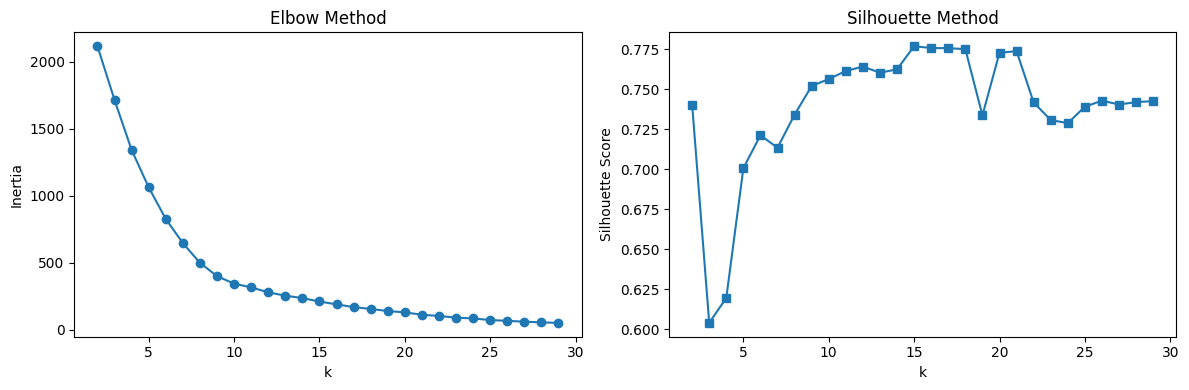

Optimal k = 15  (silhouette: 0.777)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(np.array(data_list))

inertias, sil_scores = [], []
K_range = range(2, min(30, len(X_scaled)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'o-')
ax1.set(xlabel='k', ylabel='Inertia', title='Elbow Method')
ax2.plot(K_range, sil_scores, 's-')
ax2.set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Method')
plt.tight_layout()
#plt.savefig(fig_path + 'clustering_elbow_silhouette.png')
plt.show()

optimal_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Optimal k = {optimal_k}  (silhouette: {max(sil_scores):.3f})")

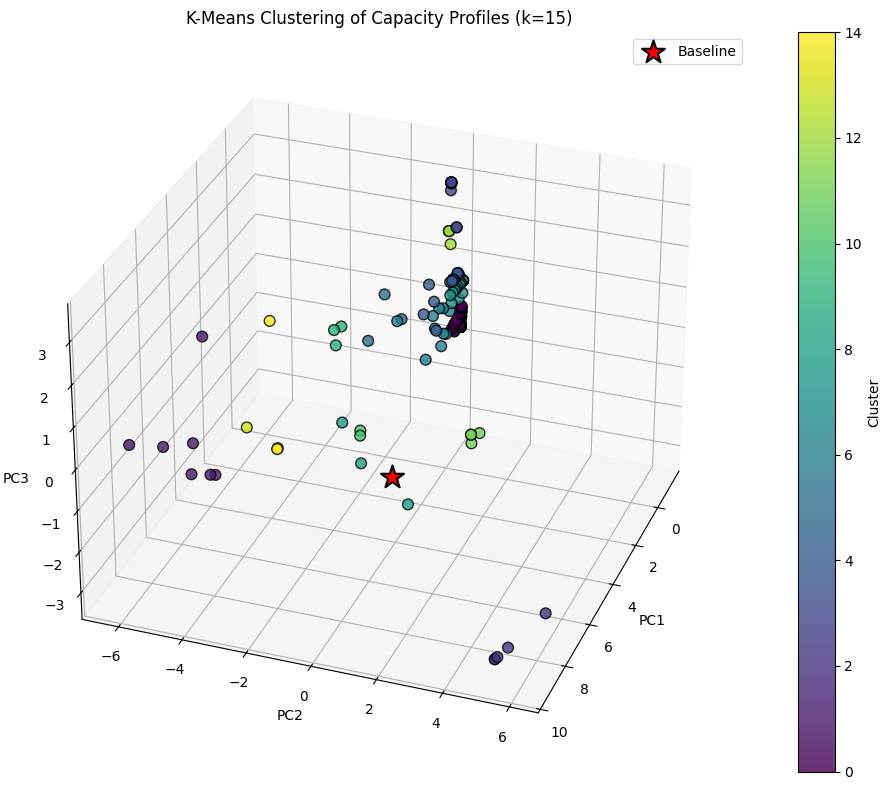

In [5]:
km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Project baseline into PCA space
baseline_p_nom = pd.concat((baseline.generators.p_nom_opt, baseline.storage_units.p_nom_opt))
baseline_scaled = scaler.transform(baseline_p_nom.values.reshape(1, -1))
baseline_pca = pca.transform(baseline_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, #cmap='tab20',
    edgecolors='k', s=60, alpha=0.8
)
ax.scatter(
    baseline_pca[:, 0], baseline_pca[:, 1], baseline_pca[:, 2],
    marker='*', s=300, c='red', edgecolors='k', linewidths=1.5,
    label='Baseline'
)
fig.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'K-Means Clustering of Capacity Profiles (k={optimal_k})')
ax.legend()

# rotate the 3D view
ax.view_init(elev=30, azim=20)

plt.tight_layout()
#plt.savefig(fig_path + 'clustering_pca_3d.png')
plt.show()

for i, (hash_id, v) in enumerate(data.items()):
    v['cluster'] = int(labels[i])

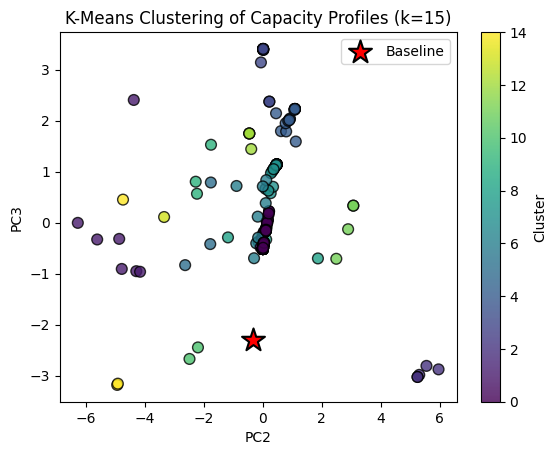

In [6]:
scatter = plt.scatter(X_pca[:, 1], X_pca[:, 2], c=labels,# cmap='tab10',
                      edgecolors='k', s=60, alpha=0.8)
plt.scatter(
    baseline_pca[:, 1], baseline_pca[:, 2],
    marker='*', s=300, c='red', edgecolors='k', linewidths=1.5,
    label='Baseline'
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC2')
plt.ylabel('PC3')
plt.title(f'K-Means Clustering of Capacity Profiles (k={optimal_k})')
plt.legend()
#plt.savefig(fig_path + 'clustering_pca.png')
plt.show()

# Store labels back in data dict
for i, (hash_id, v) in enumerate(data.items()):
    v['cluster'] = int(labels[i])

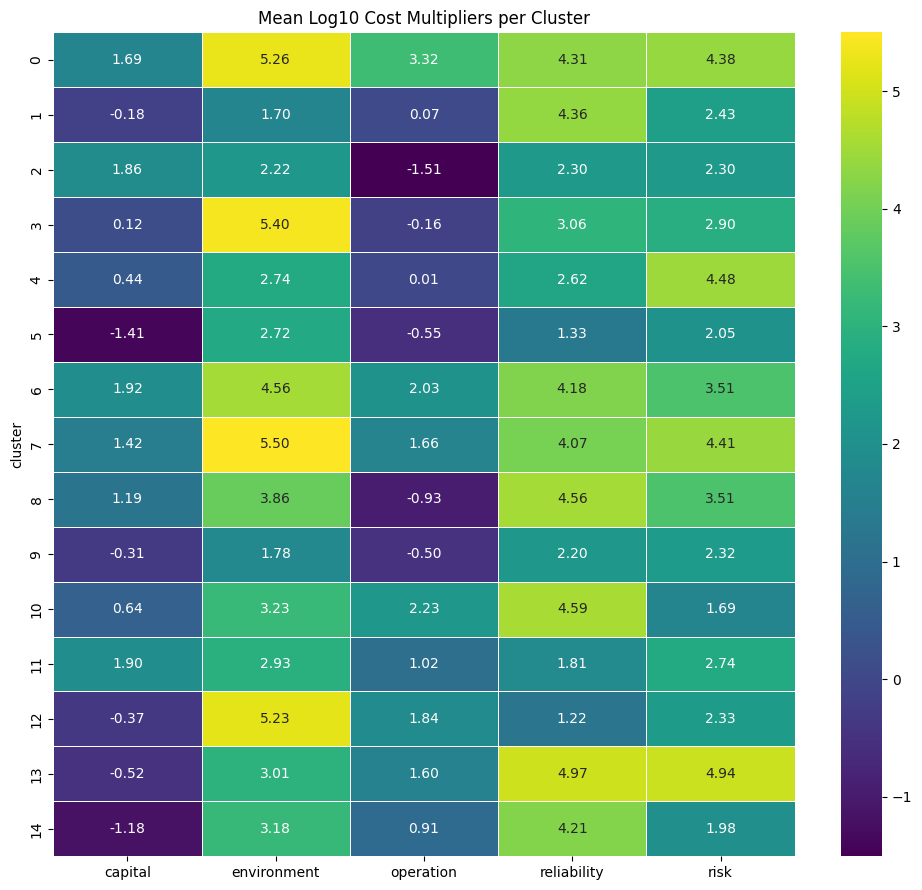


Cluster sizes:
0     201
1       7
2       5
3      13
4      16
5       3
6      10
7      25
8       3
9       3
10      2
11      4
12      4
13      1
14      3
Name: count, dtype: int64


In [8]:
# Map cost multipliers to clusters
cost_df = pd.DataFrame([
    v['metadata']['canonical_log10_cost_multipliers']
    for v in data.values()
])
cost_df['cluster'] = labels
cost_centers = cost_df.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(10, max(4, optimal_k * 0.6)))
sns.heatmap(cost_centers, cmap='viridis', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Mean Log10 Cost Multipliers per Cluster')
plt.tight_layout()
#plt.savefig(fig_path + 'clustering_cost_profiles.png')
plt.show()

print(f"\nCluster sizes:")
print(pd.Series(labels).value_counts().sort_index())